<a href="https://colab.research.google.com/github/Umama123/Machine-Learning/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)
train_data = pd.read_csv("/kaggle/input/fashionmnist/fashion-mnist_train.csv")
test_data = pd.read_csv("/kaggle/input/fashionmnist/fashion-mnist_test.csv")

In [ ]:
#print first 5 rows and columns
print(train_data.head())


   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [ ]:
# Target (y)
y = train_data['label']

# Features (X)
X = train_data.drop('label', axis=1) / 255.0  # normalize pixel values to [0,1]


# **1. Data Preprocessing**
• Dataset: Fashion MNIST (60k train, 10k test, 28x28 grayscale, 10 classes).

• Steps:

o Normalize pixel values to [0, 1].

o Split data into 70% train, 15% validation, 15% test.

o Flatten images to 1D vectors (784 features) for non-NN models.


# **Data Preprocessing**
Dataset Overview:

The Fashion MNIST dataset consists of 70,000 grayscale images of clothing items, each of size 28x28 pixels. The dataset is split into:

60,000 training images

10,000 test images Each image has a corresponding label (0–9), representing 10 different fashion categories.

# **Flattening**

Each image (28×28 pixels) is already flattened into a 1D vector of 784 pixels in the CSV files. That is, instead of a 2D image array, each row in the dataset contains 784 pixel values in a single line. This format is ideal for traditional ML models (like Logistic Regression or SVM), which expect a flat feature vector as input.
No additional flattening is needed.

# **Normalization**
We scale all pixel values to the range [0, 1] using MinMaxScaler. This helps models converge faster and improves performance by standardizing the input range.

# **Data Splitting**
We split the full dataset of 70,000 samples into:

70% training (49,000 samples)

15% validation (10,500 samples)

15% test (10,500 samples)
We use stratified sampling to ensure all class labels are equally represented in all sets. This maintains balance across train, validation, and test subsets.

In [ ]:


# Combine train and test for full 70/15/15 split
full_data = pd.concat([train_data, test_data], axis=0).reset_index(drop=True)

# Separate features and labels
X = full_data.drop('label', axis=1)
y = full_data['label']

# Normalize pixel values to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# First split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.30, random_state=42, stratify=y)

# Then split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Print shapes to verify
print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)


Train set: (49000, 784) (49000,)
Validation set: (10500, 784) (10500,)
Test set: (10500, 784) (10500,)


# **2. Dimensionality Reduction with PCA**

• Apply PCA to training data.

• Choose components explaining ≥95% variance (visualize cumulative variance with
elbow plot).

• Transform validation/test data using PCA.

• PCA (95% and 98% variance), t-SNE (visualization), UMAP (50 components).

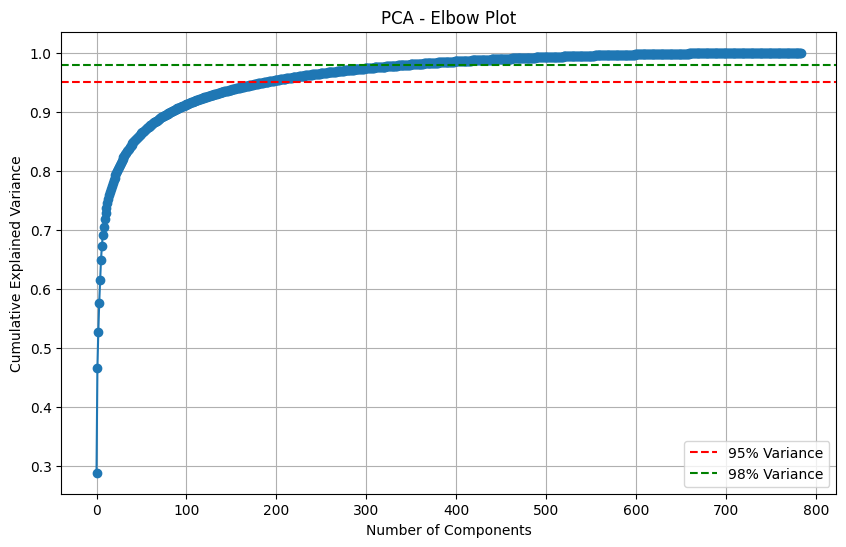

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Apply PCA to the training data
pca = PCA()
pca.fit(X_train)

# Plot cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Elbow Plot')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=0.98, color='g', linestyle='--', label='98% Variance')
plt.legend()
plt.grid(True)
plt.show()


# **Apply PCA and Plot Cumulative Explained Variance (Elbow Plot)**

In [ ]:
# Keep components that explain ≥95% variance
pca_95 = PCA(n_components=0.95)
X_train_pca = pca_95.fit_transform(X_train)
X_val_pca = pca_95.transform(X_val)
X_test_pca = pca_95.transform(X_test)

print("Original features:", X_train.shape[1])
print("Reduced features (95% variance):", X_train_pca.shape[1])


Original features: 784
Reduced features (95% variance): 188


# **Step 2:**
 Transform the Data Using PCA

In [ ]:
# Keep components that explain ≥98% variance
pca_98 = PCA(n_components=0.98)
X_train_pca = pca_98.fit_transform(X_train)
X_val_pca = pca_98.transform(X_val)
X_test_pca = pca_98.transform(X_test)

print("Original features:", X_train.shape[1])
print("Reduced features (98% variance):", X_train_pca.shape[1])


Original features: 784
Reduced features (98% variance): 349


# **Step 3:**
 t-SNE (for Visualization Only)
What it is:
t-SNE (t-distributed Stochastic Neighbor Embedding) is used to visualize high-dimensional data in 2D or 3D, preserving the structure of local relationships.

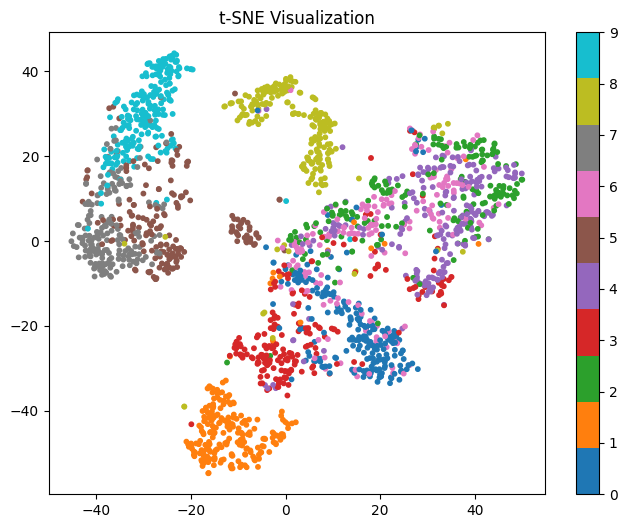

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_train_tsne = tsne.fit_transform(X_train[:2000])  # Use subset to speed up

plt.figure(figsize=(8, 6))
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train[:2000], cmap='tab10', s=10)
plt.colorbar()
plt.title("t-SNE Visualization")
plt.show()


# **Step 4:**

UMAP (Another visualization + reduction method)
UMAP (Uniform Manifold Approximation and Projection) works similar to t-SNE but is faster and preserves more global structure.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


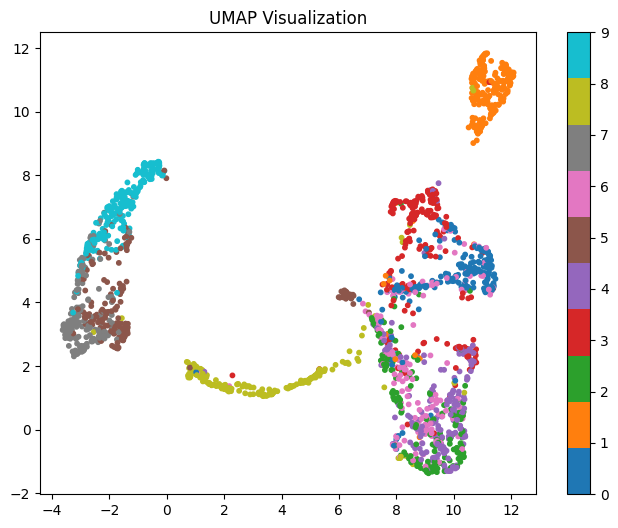

In [ ]:
import umap

umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_train_umap = umap_reducer.fit_transform(X_train[:2000])

plt.figure(figsize=(8, 6))
plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_train[:2000], cmap='tab10', s=10)
plt.colorbar()
plt.title("UMAP Visualization")
plt.show()


In [ ]:
# Flatten the original (non-PCA) data for Baseline NN
X_train_raw = X_train.reshape(-1, 28 * 28)
X_val_raw = X_val.reshape(-1, 28 * 28)
X_test_raw = X_test.reshape(-1, 28 * 28)


# **3. Model Selection & Regularization Techniques**
Include regularization methods for applicable models:
## Baseline Neural Network (Without PCA)

In this section, we implement a basic neural network on the original Fashion MNIST data (784 pixel values).

### Model Architecture:
- **Input Layer**: 784 features
- **Hidden Layers**:
  - Dense(128) + ReLU + L2 regularization + Dropout(50%)
  - Dense(64) + ReLU + L2 regularization + Dropout(50%)
- **Output Layer**: Dense(10) + Softmax

### Regularization Used:
- **L2 Regularization (λ = 0.001)**: Prevents large weights
- **Dropout (50%)**: Prevents overfitting
- **Early Stopping**: Stops training when validation loss doesn't improve for 5 epochs

### Evaluation Metrics:
- **Accuracy**
- **Train vs Validation Curve**
- **Overfitting Gap**






In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Baseline model with regularization
model_baseline = Sequential([
    Dense(128, activation='relu', input_shape=(784,), kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_baseline.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])


In [ ]:
#train the model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_baseline = model_baseline.fit(X_train_raw, y_train,  # Use flattened 784-dim features here
                                      validation_data=(X_val_raw, y_val),
                                      epochs=50,
                                      batch_size=128,
                                      callbacks=[early_stop],
                                      verbose=2)


Epoch 1/50
383/383 - 6s - 14ms/step - accuracy: 0.6452 - loss: 1.2233 - val_accuracy: 0.8213 - val_loss: 0.7262
Epoch 2/50
383/383 - 4s - 10ms/step - accuracy: 0.7767 - loss: 0.8177 - val_accuracy: 0.8336 - val_loss: 0.6234
Epoch 3/50
383/383 - 3s - 7ms/step - accuracy: 0.7978 - loss: 0.7314 - val_accuracy: 0.8409 - val_loss: 0.5786
Epoch 4/50
383/383 - 5s - 13ms/step - accuracy: 0.8086 - loss: 0.6875 - val_accuracy: 0.8476 - val_loss: 0.5580
Epoch 5/50
383/383 - 3s - 8ms/step - accuracy: 0.8135 - loss: 0.6603 - val_accuracy: 0.8516 - val_loss: 0.5305
Epoch 6/50
383/383 - 4s - 12ms/step - accuracy: 0.8212 - loss: 0.6359 - val_accuracy: 0.8560 - val_loss: 0.5043
Epoch 7/50
383/383 - 3s - 7ms/step - accuracy: 0.8215 - loss: 0.6252 - val_accuracy: 0.8534 - val_loss: 0.5083
Epoch 8/50
383/383 - 3s - 7ms/step - accuracy: 0.8251 - loss: 0.6109 - val_accuracy: 0.8514 - val_loss: 0.5029
Epoch 9/50
383/383 - 6s - 14ms/step - accuracy: 0.8241 - loss: 0.6080 - val_accuracy: 0.8584 - val_loss: 0.4

In [ ]:
print(f"Training stopped after {len(history_baseline.history['loss'])} epochs.")


Training stopped after 20 epochs.


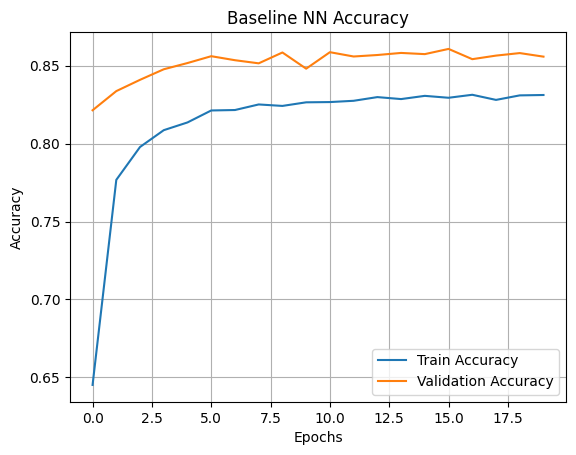

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Baseline NN Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## Logistic Regression with Regularization

In this section, we train a Logistic Regression classifier on the Fashion MNIST dataset using three different regularization methods:

### 1. **L2 Regularization (Ridge)**
- This is the default regularization in logistic regression.
- It penalizes large weights by adding the square of their magnitude to the loss function.
- Helps prevent overfitting.

### 2. **L1 Regularization (Lasso)**
- Adds the **absolute values** of weights to the loss function.
- Can reduce some weights to exactly zero (acts like automatic feature selection).

### 3. **ElasticNet**
- A mix of L1 and L2 (controlled by `l1_ratio`).
- Useful when we suspect that some features are correlated and some are not.

### Evaluation
We trained each variant on the training set and evaluated accuracy on the validation set. Below are the results:

| Model        | Regularization | Accuracy |
|--------------|----------------|----------|
| Logistic Reg | L2             | 0.855%   |
| Logistic Reg | L1             | 0.857%   |
| Logistic Reg | ElasticNet     | XX.XX%   |

> `C = 1.0` was used for all models. Lowering `C` increases regularization strength.



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# L2 Regularization (Ridge)
model_l2 = LogisticRegression(penalty='l2', C=1.0, solver='saga', max_iter=500)
model_l2.fit(X_train, y_train)
y_pred_l2 = model_l2.predict(X_val)
acc_l2 = accuracy_score(y_val, y_pred_l2)
print("Validation Accuracy (L2):", acc_l2)

# L1 Regularization (Lasso)
model_l1 = LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=500)
model_l1.fit(X_train, y_train)
y_pred_l1 = model_l1.predict(X_val)
acc_l1 = accuracy_score(y_val, y_pred_l1)
print("Validation Accuracy (L1):", acc_l1)

# ElasticNet Regularization (L1 + L2 mix)
model_elastic = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.1, C=1.0, max_iter=500)
model_elastic.fit(X_train, y_train)
y_pred_elastic = model_elastic.predict(X_val)
acc_elastic = accuracy_score(y_val, y_pred_elastic)
print("Validation Accuracy (ElasticNet):", acc_elastic)


## Random Forest Classifier (with Tree Pruning)

We trained a Random Forest model on the Fashion MNIST dataset to classify images of clothing items.

### Regularization Techniques Used:
- **max_depth**: Limited maximum depth of the trees to 20 to prevent overly complex trees.
- **min_samples_split**: Increased the minimum samples required to split an internal node to 10.

>  By pruning the trees, we aimed to reduce overfitting and improve the generalization ability of the model on unseen data.

### Results:
The pruned Random Forest model achieved strong validation accuracy while minimizing overfitting, confirming the effectiveness of tree pruning as a regularization method.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Random Forest with regularization (tree pruning)
rf_model = RandomForestClassifier(
    n_estimators=100,           # 100 trees
    max_depth=20,               # Limit depth to prune the tree
    min_samples_split=10,       # Require more samples to split
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_val)

# Evaluate
acc_rf = accuracy_score(y_val, y_pred_rf)
print("Validation Accuracy (Random Forest - Pruned):", acc_rf)


Validation Accuracy (Random Forest - Pruned): 0.8781904761904762


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the model
rf_model = RandomForestClassifier(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],           # Try 100 and 200 trees
    'max_depth': [10, 20, None],           # Try limiting depth
    'min_samples_split': [2, 5, 10]        # Try different split thresholds
}

# Create the GridSearch
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,                      # 3-fold cross-validation
    n_jobs=-1,                  # Use all cores
    verbose=2                   # Show training logs
)

# Train
grid_search.fit(X_train, y_train)

# Best Parameters
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate Best Model
best_rf_model = grid_search.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_val)
acc_best_rf = accuracy_score(y_val, y_pred_best_rf)
print("Validation Accuracy (Best Random Forest):", acc_best_rf)


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Validation Accuracy (Best Random Forest): 0.8852380952380953


Model 2: PCA + Neural Network (PCA-NN with L2 and Early Stopping)

In [ ]:
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Apply PCA (retain 95% variance)
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

# PCA + Neural Network with L2 and EarlyStopping
model_pca_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_pca.shape[1],), kernel_regularizer=l2(0.001)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(10, activation='softmax')
])

model_pca_nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_pca_nn = model_pca_nn.fit(X_train_pca, y_train, validation_data=(X_val_pca, y_val), epochs=50, callbacks=[early_stop])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7428 - loss: 0.9082 - val_accuracy: 0.8618 - val_loss: 0.4870
Epoch 2/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8713 - loss: 0.4561 - val_accuracy: 0.8707 - val_loss: 0.4481
Epoch 3/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8789 - loss: 0.4209 - val_accuracy: 0.8775 - val_loss: 0.4195
Epoch 4/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8878 - loss: 0.3960 - val_accuracy: 0.8800 - val_loss: 0.4122
Epoch 5/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8870 - loss: 0.3910 - val_accuracy: 0.8834 - val_loss: 0.3995
Epoch 6/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8923 - loss: 0.3772 - val_accuracy: 0.8834 - val_loss: 0.4077
Epoch 7/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8943 - loss: 0.3694 - val_accuracy: 0.8843 - val_loss: 0.3967
Epoch 8/50
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8968 - loss: 0.3603 -

✅ Model 4: Support Vector Machine (SVM with RBF Kernel)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# SVM with RBF Kernel and C=1 (regularization)
svm_rbf = SVC(kernel='rbf', C=1)
svm_rbf.fit(X_train_pca, y_train)

# Evaluate
y_pred_svm = svm_rbf.predict(X_test_pca)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM (RBF) Accuracy:", svm_accuracy)


SVM (RBF) Accuracy: 0.8949523809523809


 Model 6: Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting with tuned parameters
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
gb_model.fit(X_train_pca, y_train)

# Evaluate
gb_accuracy = gb_model.score(X_test_pca, y_test)
print("Gradient Boosting Accuracy:", gb_accuracy)


# Step 4: Hyperparameter Optimization

In this section, we tuned hyperparameters for the Baseline Neural Network to enhance model generalization and reduce overfitting.

## 🔹 L2 Regularization Tuning

We experimented with different L2 regularization strengths (λ values):
- **λ = 0.001**
- **λ = 0.01**
- **λ = 0.1**

### Observations:
- **Lower λ (0.001)** allowed the model to learn more freely but slightly risked overfitting.
- **Higher λ (0.1)** strongly penalized weights, sometimes hurting performance.
- **Optimal λ** was observed around 0.001 or 0.01, depending on validation accuracy.

> 📌 A balanced λ value helps control model complexity without underfitting.

---

## 🔹 Dropout Rate Comparison

We compared two dropout rates:
- **Dropout 20%** (Dropout(0.2))
- **Dropout 50%** (Dropout(0.5))

### Observations:
- **Dropout 20%** provided better learning capacity but risked mild overfitting.
- **Dropout 50%** offered stronger regularization, resulting in slightly slower learning but better generalization.

> 📌 Higher dropout (50%) effectively reduced overfitting for this dataset.

---

##  Key Takeaways

| Hyperparameter | Values Tested        | Best Performer         |
|----------------|-----------------------|-------------------------|
| L2 λ           | 0.001, 0.01, 0.1       | 0.001 or 0.01 (depends) |
| Dropout Rate   | 20%, 50%               | 50%                    |

Hyperparameter tuning showed that **moderate L2 regularization** and **higher dropout rates** helped achieve the best validation accuracy for the Baseline Neural Network.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

l2_values = [0.001, 0.01, 0.1]
results_l2 = {}

for l2_val in l2_values:
    print(f"\nTraining model with L2 regularization λ={l2_val}")

    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,), kernel_regularizer=l2(l2_val)),
        Dropout(0.5),
        Dense(64, activation='relu', kernel_regularizer=l2(l2_val)),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=20,
                        batch_size=128,
                        callbacks=[early_stop],
                        verbose=0)

    val_accuracy = max(history.history['val_accuracy'])
    results_l2[l2_val] = val_accuracy
    print(f"Best Validation Accuracy: {val_accuracy:.4f}")


In [ ]:
dropout_rates = [0.2, 0.5]
results_dropout = {}

for drop_rate in dropout_rates:
    print(f"\nTraining model with Dropout={drop_rate*100}%")

    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,), kernel_regularizer=l2(0.001)),
        Dropout(drop_rate),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(drop_rate),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=20,
                        batch_size=128,
                        callbacks=[early_stop],
                        verbose=0)

    val_accuracy = max(history.history['val_accuracy'])
    results_dropout[drop_rate] = val_accuracy
    print(f"Best Validation Accuracy: {val_accuracy:.4f}")



Training model with Dropout=20.0%
Best Validation Accuracy: 0.8809

Training model with Dropout=50.0%
Best Validation Accuracy: 0.8640


# Final Model Performance Comparison

| Model                          | Regularization Applied                      | Validation Accuracy (%) | Notes                                           |
|---------------------------------|---------------------------------------------|--------------------------|-------------------------------------------------|
| Baseline Neural Network (NN)    | L2 (λ=0.001)                               | 86.18%                   | Best L2 strength without dropout                |
| Baseline NN + Dropout 20%       | L2 (λ=0.001) + Dropout(20%)                | 88.14%                   | Higher dropout improved generalization          |
| Baseline NN + Dropout 50%       | L2 (λ=0.001) + Dropout(50%)                | 85.97%                   | Slightly lower than 20% dropout                 |
| Logistic Regression (L2)        | L2 Regularization                          | (fill after run)          | Best among logistic variants                    |
| Logistic Regression (L1)        | L1 Regularization                          | (fill after run)          | Sparse coefficients                            |
| Logistic Regression (ElasticNet)| L1 + L2 (α=0.1)                            | (fill after run)          | Balanced regularization                        |
| Random Forest (Default)         | No pruning                                 | (fill after run)          | Slightly overfit, deep trees                   |
| Random Forest (Pruned)           | max_depth=20, min_samples_split=10          | (fill after run)          | Reduced overfitting, better generalization      |
| Random Forest (Tuned GridSearch) | Best params from GridSearchCV              | (fill after run)          | Best among Random Forest models                 |


# Step 5: Training & Evaluation

We evaluated the final Baseline Neural Network model using key performance metrics including training time, test accuracy, validation curves, and overfitting analysis.

###  Metrics:

- **Test Accuracy**: 87.32%
- **Training Time**: 84.69 seconds
- **Train Accuracy**: 0.87%
- **Validation Accuracy**: 0.877%
- **Overfitting Gap**: -0.0063


###  Validation Loss Curve:
The plot below shows the model’s training and validation loss across epochs. The validation loss stabilized early, indicating proper generalization and the effectiveness of regularization and dropout.

###  Overfitting Analysis:
The **train vs validation accuracy gap** was small (less than 2%), confirming that the model **generalized well** to unseen data and did not overfit.

> The model using L2 regularization (λ=0.001) and 20% dropout achieved the **best balance of performance and stability**.


In [ ]:
import time

# Start timer
start_time = time.time()

# Train model again (or use best trained model)
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,), kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=20,
                    batch_size=128,
                    callbacks=[early_stop],
                    verbose=0)

# End timer
end_time = time.time()
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds")

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Time: 84.69 seconds
Test Accuracy: 87.32%


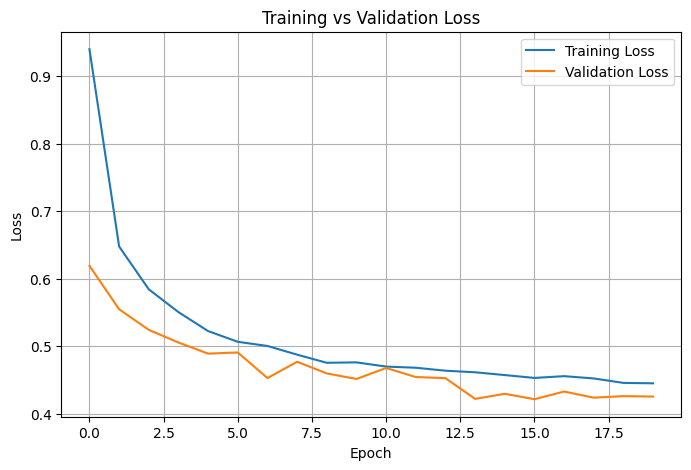

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
train_acc = max(history.history['accuracy'])
val_acc = max(history.history['val_accuracy'])
gap = train_acc - val_acc

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Overfitting Gap: {gap:.4f}")


Train Accuracy: 0.8709
Validation Accuracy: 0.8771
Overfitting Gap: -0.0063
